Author: Naveen Mendola


Email: naveen.maindola95@gmail.com

Affiliation: Bennett University
Ph.D. Supervisor: Dr. Umeshkanta Singh

Please feel free to use and upgrade. Let me know what you created.

In [ ]:
using DifferentialEquations
using Plots
# using LaTeXStrings
# using Distributions
# using TestImages
using FileIO
using Images
# using FFTW
using DelimitedFiles

N = 3

In [ ]:


function lorentz_3os(du, u, p, t)
    (σ, ρ, β, K, δ) = p

    du[1] = σ * (u[2] - u[1]) + K * (u[7] - 2 * u[1] + u[4])
    du[2] = u[1] * (ρ - u[3]) - u[2]
    du[3] = u[1] * u[2] - β * u[3]

    du[4] = σ * (u[5] - u[4]) + K * (u[1] - 2 * u[4] + u[7]) + δ * (u[7] - u[4])
    du[5] = u[4] * (ρ - u[6]) - u[5]
    du[6] = u[4] * u[5] - β * u[6]

    du[7] = σ * (u[8] - u[7]) + K * (u[1] - 2 * u[7] + u[4]) + δ * (u[4] - u[7])
    du[8] = u[7] * (ρ - u[9]) - u[8]
    du[9] = u[7] * u[8] - β * u[9]

    # du are assigned like this deliberately. Easily modify the function for N 
    # oscillators with something like
    # for i=1:N
    #      du[i] = σ * (u[i+N] - u[i]) + K * sum(your_network[i, :] .* u[1:N])
    #      du[i+N] = u[i] * (ρ - u[i+2N]) - u[i+N]
    #      du[i+2N] = u[i] * u[i+N] - β * u[i+2N]
    # end

    nothing
end

lorentz_3os (generic function with 1 method)

In [ ]:
tf = 100; dt = 0.005;
tspan = (0, tf);

# Initialize
# u0 = rand(Uniform(5, 25), 3*N)
u0 = [12.32; 19.06; 17.24; 
      12.320000000001; 19.060000000001; 17.240000000001; 
      12.320000000002; 19.060000000002; 17.240000000002; ]; # 2 os are close.

In [5]:
σ=10;
ρ=28; β=8/3;


K = 0; δ=0;

p = (σ, ρ, β, K, δ)

prob = ODEProblem(lorentz_3os, u0, tspan, p)
sol = solve(prob, saveat=dt; abstol=1e-8, reltol=1e-6)
# sol = transpose(Array(sol))
println(size(sol))
x1 = sol[1, :]  # x₁(t)
x2 = sol[4, :]  # x₂(t)
x3 = sol[7, :]  # x₃(t)

y1 = sol[2, :]
y2 = sol[5, :]
y3 = sol[8, :]

z1 = sol[3, :]
z2 = sol[6, :]
z3 = sol[9, :];

sol1 = transpose(Array(sol));

(9, 20001)


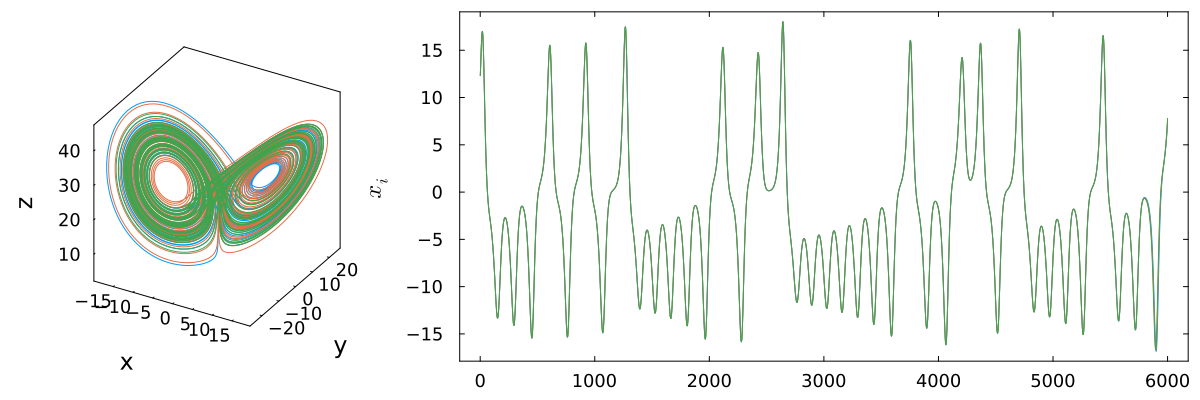

In [ ]:
# test plot
index_sub = 10000

# layout=@layout[
#         0.3w 0.7w
#     ]

p1= plot(sol1[end-index_sub:end, 1], sol1[end-index_sub:end, 2], sol1[end-index_sub:end, 3], label="")
p1 = plot!(sol1[end-index_sub:end, 4], sol1[end-index_sub:end, 5], sol1[end-index_sub:end, 6], label="")
p1 = plot!(sol1[end-index_sub:end, 7], sol1[end-index_sub:end, 8], sol1[end-index_sub:end, 9], label="")
p1 = plot!(xguide="x", yguide="y", zguide="z", frame=:box, grid=:none)

p2 = plot(sol1[1:6000, 1], label="")
p2 = plot!(sol1[1:6000, 4], label="", yguide=L"x_{i}", xguide=L"t", frame=:box)
p2 = plot!(sol1[1:6000, 7], label="", grid=:none)

plot(p1, p2, layout=grid(1, 2, widths=[0.3, 0.7]), size=(1200, 400), guidefontsize=16, tickfontsize=12)

# savefig("timeseries_delta=$(δ)_K=$(K).pdf")

In [ ]:
rocket1 = load("sprites/r1.png");
rocket2 = load("sprites/r2.png");
rocket3 = load("sprites/r3.png");

In [ ]:
xmin, xmax = extrema(x1)
ymin, ymax = extrema(y1)
zmin, zmax = extrema(z1)

dx = 8; dy=8


anim = @animate for i in 2:2:400
    plot(x1[1:i], y1[1:i], lw=2, color=:blue, legend=false,
         xlim=(xmin, xmax), ylim=(ymin, ymax), size=(600, 400))

    x0 = x1[i] - dx/2
    y0 = y1[i] - dy/2

    rocket1_head = atan(y1[i] - y1[i-1], x1[i] - x1[i-1])

    
    rocket1_rotated = imrotate(rocket1, (π/2 + rocket1_head), axes=(:crop))
    
    plot!([x0, x0+dx], -[y0, y0+dy], rocket1_rotated, grid=:none, frame=:box)
end

mp4(anim, "lorenz_rocket1.mp4", fps=30)

In [12]:
xmin, xmax = extrema(x1)
ymin, ymax = extrema(y1)
zmin, zmax = extrema(z1)

dx = 8; dz=8

anim = @animate for i in 6200:1:6340 # 9700
    print("\r $(i)")

    plot(x1[1:end], z1[1:end], lw=0.7, color=RGB(40/256, 40/256, 40/256), legend=false, alpha=0.1)
    plot!(x1[1:i], z1[1:i], lw=0.8, legend=false, xlim=(-20, 20), ylim=(zmin, zmax),
         palette=:Dark2_3, c=:1:i, line_z=1:i
        ) # palette=:turbo

    x0 = x1[i] - dx/2
    z0 = z1[i] - dz
    # println(z0)

    rocket_head = atan(z1[i] - z1[i-1], x1[i] - x1[i-1])

    rocket_rotated = 0
    
    if i%3==0
        rocket_rotated = imrotate(rocket1, (π/2 + rocket_head)) #, axes=(:crop))
    elseif i%3==1
        rocket_rotated = imrotate(rocket2, (π/2 + rocket_head)) #, axes=(:crop))
    elseif i%3==2
        rocket_rotated = imrotate(rocket3, (π/2 + rocket_head)) #, axes=(:crop))
    end
    
    # rocket_rotated = imrotate(rocket1, (π/2 + rocket_head)) #, axes=(:crop))
    
    plot!([x0, x0+dx], [zmax-z0, zmax-z0-dz], rocket_rotated, grid=:none, aspect_ratio = (zmax-zmin) / 50,
        transposey=true, background=:transparent, axis=false)
end


mp4(anim, "lor_rockets_w_stars.mp4", fps=70);


 6340

[ Info: Saved animation to /Users/naveen/Documents/lorentz_rocket/lor_rockets_w_stars.mp4


In [90]:
# Old functions for stars
# function insert_stars(plot_ob, change_loc)
#     global stars_locx, stars_locy, stars_size, change_stars_loc, pfps
#     if change_loc == true
#         update_stars_loc()
#         change_stars_loc = false
#     end

#     stars_size = stars_size .+ 0.02;
#     # if maximum(stars_size) .>= 4.5
#     #     stars_size = stars_size .- 0.02;
#     # else 
#     #     stars_size = stars_size .+ 0.02;
#     # end
#     plot_ob = scatter!(stars_locx, stars_locy, label="",
#         markershape=:star5, ms=stars_size, c=RGB(192/255, 192/255, 192/255), ma=0.5, msa=0, msw=1, msc=:white) #, msc=nothing)
# end

# function update_stars_loc()
#     global stars_locx, stars_locy, stars_size, n_stars
    
#     n_stars = Int(rand(80:140));

#     stars_locx, stars_locy = rand(Uniform(-20, 20), n_stars), rand(Uniform(zmin, zmax), n_stars)
#     stars_size = rand(Uniform(0, 3), n_stars)
# end

update_stars_loc (generic function with 1 method)

In [29]:
function insert_stars(plot_ob, change_loc)
    global n_stars, stars_locx, stars_locy, stars_size, change_stars_loc, pfps
    if change_loc == true
        update_stars_loc()
        change_stars_loc = false
    end

    stars_size = stars_size .+ 0.02;
    # if maximum(stars_size) .>= 4.5
    #     stars_size = stars_size .- 0.02;
    # else 
    #     stars_size = stars_size .+ 0.02;
    # end
    plot_ob = scatter!(stars_locx, stars_locy, label="",
        markershape=:star5, ms=stars_size.+rand(Uniform(-0.5, 0.5), n_stars), c=:white, 
        ma=0.5, msa=0, msw=1, msc=1:n_stars) 
    #RGB(192/255, 192/255, 192/255) marker_z=1:n_stars,  c=:gist_ncar
end

function update_stars_loc()
    global stars_locx, stars_locy, stars_size, mean_stars, n_stars
    
    n_stars = Int(rand(mean_stars-100:mean_stars+50));

    θs = rand(Normal(π/2, 5), n_stars)
    rs = rand(Uniform(zmin+12, zmax), n_stars)
    
    stars_locx = rs .* cos.(θs); stars_locy = zmax /2 .+ rs .* sin.(θs);

    # stars_locx, stars_locy = rand(Uniform(-20, 20), n_stars), rand(Uniform(zmin, zmax), n_stars)
    stars_size = rand(Uniform(0, 0.6), n_stars)
end

update_stars_loc (generic function with 1 method)

In [43]:
rocket1 = load("sprites/sput1-1.png");
rocket2 = load("sprites/sput1-2.png");
rocket3 = load("sprites/sput1-3.png");
rocket4 = load("sprites/sput1-4.png");

rocket11 = load("sprites/sput2-1.png");
rocket12 = load("sprites/sput2-2.png");
rocket13 = load("sprites/sput2-3.png");
rocket14 = load("sprites/sput2-4.png");

# For 2 Sputnik1

In [197]:
xmin, xmax = extrema(x1);
ymin, ymax = extrema(y1);
zmin, zmax = extrema(z1);

xmin1, xmax1 = extrema(x2);
ymin1, ymax1 = extrema(y2);
zmin1, zmax1 = extrema(z2);


pfps = 50

n_stars = 400

θs = rand(Normal(π/2, 5), n_stars)
rs = rand(Uniform(zmin+12, zmax), n_stars)

stars_locx = rs .* cos.(θs); stars_locy = zmax /2 .+ rs .* sin.(θs);
# stars_locx = rand(Uniform(-20, 20), n_stars)
# stars_locy = rand(Uniform(zmin, zmax), n_stars)
stars_size = rand(Uniform(0, 0.6), n_stars)
change_stars_loc = false

dx = 10; dz=10

first_frame, last_frame = 5500, 5900 # 10000

anim = @animate for i in first_frame:1:last_frame # 9700
    
    print("\rframe: $(i)")

    plot_obj = plot(x1[1:i-4500], z1[1:i-4500], lw=0.7, color=RGB(40/256, 40/256, 40/256), legend=false)

    if i%(3*pfps)==0
        global change_stars_loc = true
    end
    if i >= first_frame + 200
        insert_stars(plot_obj, change_stars_loc)
    end
    
    plot_obj = plot!(x1[i-5000:i], z1[i-5000:i], lw=0.8, legend=false, xlim=(-20, 20), ylim=(zmin-1, zmax+1),
         palette=:hsv, c=i-5000:i, line_z=i-5000:i, la=LinRange(0.1, 1, 5001) ) # palette=:turbo, :rainbow, gist_ncar

    x0 = x1[i] - dx/2;
    z0 = z1[i] - dz;

    x01 = x2[i] - dx/2;
    z01 = z2[i] - dz;
    # println(z0)

    rocket_head = atan(z1[i] - z1[i-1], x1[i] - x1[i-1])
    rocket_head1 = atan(z2[i] - z2[i-1], x2[i] - x2[i-1])

    rocket_rotated = 0; rocket1_rotated = 0
    
    if i%20<=5
        rocket_rotated = imrotate(rocket1, (π/2 + rocket_head)) #, axes=(:crop))
        rocket1_rotated = imrotate(rocket11, (π/2 + rocket_head1))
    elseif i%20>5 && i%20<=10
        rocket_rotated = imrotate(rocket2, (π/2 + rocket_head)) #, axes=(:crop))
        rocket1_rotated = imrotate(rocket12, (π/2 + rocket_head1))
    elseif i%20>10 && i%20<=15
        rocket_rotated = imrotate(rocket3, (π/2 + rocket_head)) #, axes=(:crop))
        rocket1_rotated = imrotate(rocket13, (π/2 + rocket_head1))
    elseif i%20>15
        rocket_rotated = imrotate(rocket4, (π/2 + rocket_head))
        rocket1_rotated = imrotate(rocket14, (π/2 + rocket_head1))
    end
    
    # rocket_rotated = imrotate(rocket1, (π/2 + rocket_head)) #, axes=(:crop))
    
    plot_obj = plot!([x0, x0+dx], [zmax-z0, zmax-z0-dz], rocket_rotated, grid=:none, aspect_ratio = (zmax-zmin) / 50,
        transposey=true, background=:transparent, axis=false) #, dpi=600)
    plot_obj = plot!([x01, x01+dx], [zmax1-z01, zmax1-z01-dz], rocket1_rotated, grid=:none, aspect_ratio = (zmax1-zmin1) / 50,
        transposey=true, background=:transparent, axis=false, dpi=600)
end


mp4(anim, "lor_2rockets_1.mp4", fps=pfps);


frame: 5900

[ Info: Saved animation to /Users/naveen/Documents/lorentz_rocket/lor_2rockets_1.mp4


# For 3 Sputnik1

In [9]:
rocket1 = load("sprites/sput1-1.png");
rocket2 = load("sprites/sput1-2.png");
rocket3 = load("sprites/sput1-3.png");
rocket4 = load("sprites/sput1-4.png");

rocket11 = load("sprites/sput2-1.png");
rocket12 = load("sprites/sput2-2.png");
rocket13 = load("sprites/sput2-3.png");
rocket14 = load("sprites/sput2-4.png");

rocket21 = load("sprites/sput3-1.png");
rocket22 = load("sprites/sput3-2.png");
rocket23 = load("sprites/sput3-3.png");
rocket24 = load("sprites/sput3-4.png");

In [28]:
xmin, xmax = extrema(x1);
ymin, ymax = extrema(y1);
zmin, zmax = extrema(z1);

xmin1, xmax1 = extrema(x2);
ymin1, ymax1 = extrema(y2);
zmin1, zmax1 = extrema(z2);

xmin2, xmax2 = extrema(x3);
ymin2, ymax2 = extrema(y3);
zmin2, zmax2 = extrema(z3);


pfps = 50

mean_stars = 400; 
n_stars = copy(mean_stars); 

θs = rand(Normal(π/2, 5), n_stars)
rs = rand(Uniform(zmin+12, zmax), n_stars)

stars_locx = rs .* cos.(θs); stars_locy = zmax /2 .+ rs .* sin.(θs);
# stars_locx = rand(Uniform(-20, 20), n_stars)
# stars_locy = rand(Uniform(zmin, zmax), n_stars)
stars_size = rand(Uniform(0, 0.6), n_stars)
change_stars_loc = false

dx = 10; dz=10

first_frame, last_frame = 5280, 9780 # 5500, 5900 # 10000

anim = @animate for i in first_frame:1:last_frame # 9700
    
    print("\rframe: $(i)")

    plot_obj = plot(x1[1:i-4500], z1[1:i-4500], lw=0.7, color=RGB(40/256, 40/256, 40/256), legend=false)

    if i%(3*pfps)==0
        global change_stars_loc = true
    end
    if i >= first_frame + 200
        insert_stars(plot_obj, change_stars_loc)
    end
    
    plot_obj = plot!(x1[i-5000:i], z1[i-5000:i], lw=0.8, legend=false, xlim=(-20, 20), ylim=(zmin-1, zmax+1),
         palette=:hsv, c=i-5000:i, line_z=i-5000:i, la=LinRange(0.1, 1, 5001) ) # palette=:turbo, :rainbow, gist_ncar

    x0 = x1[i] - dx/2;
    z0 = z1[i] - dz;

    x01 = x2[i] - dx/2;
    z01 = z2[i] - dz;

    x02 = x3[i] - dx/2;
    z02 = z3[i] - dz;
    # println(z0)

    rocket_head = atan(z1[i] - z1[i-1], x1[i] - x1[i-1])
    rocket_head1 = atan(z2[i] - z2[i-1], x2[i] - x2[i-1])
    rocket_head2 = atan(z3[i] - z3[i-1], x3[i] - x3[i-1])

    rocket_rotated = 0; rocket1_rotated = 0; rocket2_rotated = 0
    
    if i%20<=5
        rocket_rotated = imrotate(rocket1, (π/2 + rocket_head)) #, axes=(:crop))
        rocket1_rotated = imrotate(rocket11, (π/2 + rocket_head1))
        rocket2_rotated = imrotate(rocket21, (π/2 + rocket_head2))
    elseif i%20>5 && i%20<=10
        rocket_rotated = imrotate(rocket2, (π/2 + rocket_head)) #, axes=(:crop))
        rocket1_rotated = imrotate(rocket12, (π/2 + rocket_head1))
        rocket2_rotated = imrotate(rocket22, (π/2 + rocket_head2))
    elseif i%20>10 && i%20<=15
        rocket_rotated = imrotate(rocket3, (π/2 + rocket_head)) #, axes=(:crop))
        rocket1_rotated = imrotate(rocket13, (π/2 + rocket_head1))
        rocket2_rotated = imrotate(rocket23, (π/2 + rocket_head2))
    elseif i%20>15
        rocket_rotated = imrotate(rocket4, (π/2 + rocket_head))
        rocket1_rotated = imrotate(rocket14, (π/2 + rocket_head1))
        rocket2_rotated = imrotate(rocket24, (π/2 + rocket_head2))
    end
    
    # rocket_rotated = imrotate(rocket1, (π/2 + rocket_head)) #, axes=(:crop))
    
    plot_obj = plot!([x0, x0+dx], [zmax-z0, zmax-z0-dz], rocket_rotated, grid=:none, aspect_ratio = (zmax-zmin) / 50,
        transposey=true, background=:transparent, axis=false) #, dpi=600)
    plot_obj = plot!([x01, x01+dx], [zmax1-z01, zmax1-z01-dz], rocket1_rotated, grid=:none, aspect_ratio = (zmax1-zmin1) / 50,
        transposey=true, background=:transparent, axis=false) #, dpi=600)
    plot_obj = plot!([x02, x02+dx], [zmax2-z02, zmax2-z02-dz], rocket2_rotated, grid=:none, aspect_ratio = (zmax2-zmin2) / 50,
        transposey=true, background=:transparent, axis=false, dpi=600)
end


mp4(anim, "lor_3rockets_1.mp4", fps=pfps);


frame: 9780

[ Info: Saved animation to /Users/naveen/Documents/lorentz_rocket/lor_3rockets_1.mp4


In [12]:
Int(rand(n_stars-100:n_stars+50))

-99

In [13]:
n_stars

-16

In [21]:
rand(1:6)

6

In [177]:
function insert_stars(plot_ob, change_loc)
    global stars_locx, stars_locy, stars_size, change_stars_loc, pfps
    if change_loc == true
        update_stars_loc()
        change_stars_loc = false
    end

    stars_size = stars_size .+ 0.02;
    # if maximum(stars_size) .>= 4.5
    #     stars_size = stars_size .- 0.02;
    # else 
    #     stars_size = stars_size .+ 0.02;
    # end
    plot_ob = scatter!(stars_locx, stars_locy, label="",
        markershape=:star5, ms=stars_size, c=:cool, marker_z=1:n_stars, ma=0.5, msa=0, msw=1, msc=:white) #,RGB(192/255, 192/255, 192/255)
end

function update_stars_loc()
    global stars_locx, stars_locy, stars_size, n_stars
    
    n_stars = Int(rand(250:400));

    θs = rand(Normal(π/2, 5), n_stars)
    rs = rand(Uniform(zmin+12, zmax), n_stars)
    
    stars_locx = rs .* cos.(θs); stars_locy = zmax /2 .+ rs .* sin.(θs);

    # stars_locx, stars_locy = rand(Uniform(-20, 20), n_stars), rand(Uniform(zmin, zmax), n_stars)
    stars_size = rand(Uniform(0, 3), n_stars)
end

update_stars_loc (generic function with 1 method)

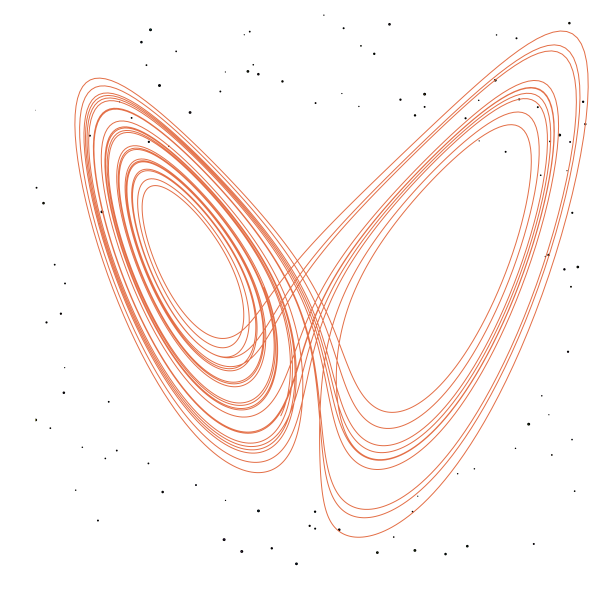

In [55]:



θs = rand(Normal(π/2, 5), n_stars)
rs = rand(Uniform(zmin+12, zmax), n_stars)

index_sub = 5000

stars_locx = rs .* cos.(θs); stars_locy = zmax /2 .+ rs .* sin.(θs);

scatter(stars_locx, stars_locy, label="", ms=rand(Uniform(0, 1), n_stars), c=:gist_ncar, marker_z=1:n_stars, colorbar=false,
    grid=:none, axis=false, size=(600 ,600))
# plot!(sol1[end-index_sub:end, 1], sol1[end-index_sub:end, 3], label="", xlim=(xmin, xmax), ylim=(zmin, zmax))
plot!(sol1[5200-index_sub:5200, 1], sol1[5200-index_sub:5200, 3], label="", xlim=(xmin, xmax), ylim=(zmin, zmax))



In [39]:
index_sub

10000